In [1]:
path = '/home/apolo/Documents/GitHubProjects/RippleProject/'

scripts_path = path + '/scripts/'
tables_path = path + '/tables/'
figures_path = path + '/figures/'


In [2]:

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns

from statsmodels.stats.proportion import proportions_chisquare

%matplotlib widget

In [3]:
import warnings
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")


In [4]:
import matplotlib
print(matplotlib.matplotlib_fname())


/home/apolo/.pyenv/versions/information_Metrics/lib/python3.11/site-packages/matplotlib/mpl-data/matplotlibrc


In [ ]:
# I had to create a function that edits out some clip path
# hf.delete_clip_path(fig_name)

# Also, when generating violin plots, we need to convert the violin object to path so we can edit its stroke correctly.
# Shortcut: Ctrl + shift + c



In [3]:
import matplotlib.font_manager
set([f.name for f in matplotlib.font_manager.fontManager.ttflist])

{'Abyssinica SIL',
 'Andale Mono',
 'Ani',
 'AnjaliOldLipi',
 'Arial',
 'Arial Black',
 'C059',
 'Chandas',
 'Chilanka',
 'Comic Sans MS',
 'Courier New',
 'D050000L',
 'DejaVu Math TeX Gyre',
 'DejaVu Sans',
 'DejaVu Sans Display',
 'DejaVu Sans Mono',
 'DejaVu Serif',
 'DejaVu Serif Display',
 'Dhurjati',
 'Droid Sans Fallback',
 'Dyuthi',
 'FontAwesome',
 'FreeMono',
 'FreeSans',
 'FreeSerif',
 'Gargi',
 'Garuda',
 'Gayathri',
 'Georgia',
 'Gidugu',
 'Gubbi',
 'Gurajada',
 'Impact',
 'Jamrul',
 'KacstArt',
 'KacstBook',
 'KacstDecorative',
 'KacstDigital',
 'KacstFarsi',
 'KacstLetter',
 'KacstNaskh',
 'KacstOffice',
 'KacstOne',
 'KacstPen',
 'KacstPoster',
 'KacstQurn',
 'KacstScreen',
 'KacstTitle',
 'KacstTitleL',
 'Kalapi',
 'Kalimati',
 'Karumbi',
 'Keraleeyam',
 'Khmer OS',
 'Khmer OS System',
 'Kinnari',
 'LKLUG',
 'LakkiReddy',
 'Laksaman',
 'Latin Modern Math',
 'Latin Modern Mono',
 'Latin Modern Mono Caps',
 'Latin Modern Mono Light',
 'Latin Modern Mono Light Cond',
 'L

In [4]:
set([f.name for f in matplotlib.font_manager.fontManager.afmlist])

{'Bitstream Charter',
 'C059',
 'Century Schoolbook L',
 'Computer Modern',
 'Courier',
 'Courier 10 Pitch',
 'D050000L',
 'Dingbats',
 'Helvetica',
 'ITC Avant Garde Gothic',
 'ITC Bookman',
 'ITC Zapf Chancery',
 'ITC Zapf Dingbats',
 'LMMono10',
 'LMMonoCaps10',
 'LMMonoLt10',
 'LMMonoLtCond10',
 'LMMonoProp10',
 'LMMonoPropLt10',
 'LMMonoSlant10',
 'LMRoman10',
 'LMRomanCaps10',
 'LMRomanDemi10',
 'LMRomanDunh10',
 'LMRomanSlant10',
 'LMRomanUnsl10',
 'LMSans10',
 'LMSansDemiCond10',
 'LMSansQuot8',
 'New Century Schoolbook',
 'Nimbus Mono L',
 'Nimbus Mono PS',
 'Nimbus Roman',
 'Nimbus Roman No9 L',
 'Nimbus Sans',
 'Nimbus Sans L',
 'Nimbus Sans Narrow',
 'P052',
 'Palatino',
 'Standard Symbols L',
 'Standard Symbols PS',
 'Symbol',
 'TeXGyreAdventor',
 'TeXGyreBonum',
 'TeXGyreChorus',
 'TeXGyreCursor',
 'TeXGyreHeros',
 'TeXGyreHerosCondensed',
 'TeXGyrePagella',
 'TeXGyreSchola',
 'TeXGyreTermes',
 'Times',
 'URW Bookman',
 'URW Bookman L',
 'URW Chancery L',
 'URW Gothic',
 

In [8]:
# https://matplotlib.org/stable/users/explain/text/text_props.html
plt.rcParams['font.sans-serif']


['Arial']

In [4]:
# Say, "the default sans-serif font is COMIC SANS"
plt.rcParams['font.sans-serif'] = "Arial"
# Then, "ALWAYS use sans-serif fonts"
plt.rcParams['font.family'] = "sans-serif"


In [5]:
os.chdir(tables_path + '/figure_2/')

filename = 'Figure_Ripple_Abundance_Overall.csv'
df = pd.read_csv(filename)
df

,rat,session,shank_side,shank_distance,ripple_abundance
0,Ach,Achilles_10252013,left,0.0,0.500833
1,Ach,Achilles_10252013,left,200.0,0.500000
2,Ach,Achilles_10252013,left,400.0,0.488611
3,Ach,Achilles_10252013,left,600.0,0.481111
4,Ach,Achilles_10252013,left,800.0,0.479167
...,...,...,...,...,...
103,Gat,Gatsby_08282013,right,600.0,0.466389
104,Gat,Gatsby_08282013,right,800.0,0.588056
105,Gat,Gatsby_08282013,right,1000.0,0.589444
106,Gat,Gatsby_08282013,right,1200.0,0.622500


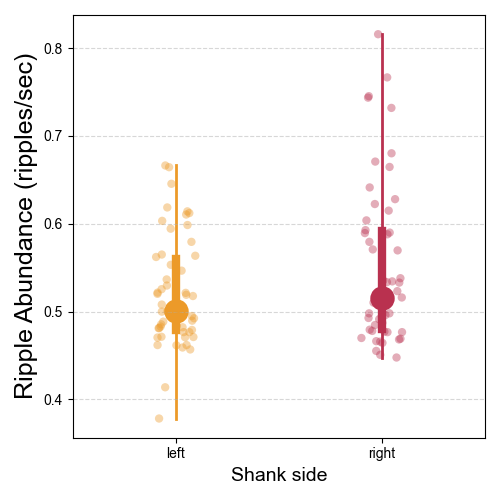

In [6]:
# testing colors

plt.close('all')
plt.figure(figsize=(5,5))

plt.rcParams['svg.fonttype'] = 'none' #when saving svg, keep text as text


# my_pal={"left": "magenta", "right": "orange"}
# my_pal ={"left": "#C08081","right":"#6B8E23"}
# my_pal ={"left": "#7B9BAE","right":"#DAC6A9"}
# my_pal ={"left": "#E8C547","right":"#5E7B7B"}
# my_pal ={"left": "#ec9a29","right":"#3a4f41"}
my_pal ={"left": "#ec9a29","right":"#b9314f"}

sns.stripplot(data=df, x="shank_side",hue="shank_side",y="ripple_abundance", order=["left", "right"],
              palette=my_pal,size=6,legend=False,alpha=0.4)
sns.pointplot(data=df,x='shank_side',hue="shank_side",y='ripple_abundance', order=["left", "right"],
              estimator='median',errorbar=("pi",50), palette=my_pal,capsize=0, join=False,errwidth=6,scale=2)
sns.pointplot(data=df,x='shank_side',hue="shank_side",y='ripple_abundance', order=["left", "right"],
              estimator='median',errorbar=("pi",100), palette=my_pal,capsize=0, join=False,errwidth=2,scale=0)

plt.ylabel('Ripple Abundance (ripples/sec)',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)

plt.tight_layout()
os.chdir(figures_path + '/figure_2/')

fig_name = 'Figure_Ripple_Abundance_Overall'
# plt.savefig(fig_name,transparent=True,format='svg')
plt.show()
 


